In [2]:
import dolfin
print("dolfin version:", dolfin.__version__)

dolfin version: 2019.1.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time

from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

import os

from dolfin import *

In [4]:
from tqdm import tqdm  # pour les barres de progression dans les boucles

In [5]:
mesh_size = 200 
FE_type = "Lagrange"
degree = 2

mesh = UnitSquareMesh(mesh_size, mesh_size)
V = FunctionSpace(mesh, FE_type, degree)
print("Number of vertices:", mesh.num_vertices())

lines = {"mesh_size": mesh_size, "FE_type": FE_type, "degree": degree}
df_mesh_info = pd.DataFrame(lines, index=[0])

Number of vertices: 40401


In [6]:
# Boundary condition
class ConditionalBC(UserExpression):
    def eval(self, values, x):
        if x[0] < 0.1 and x[1] > 0.9:
            values[0] = 4.0
        elif x[1] < 0.1:
            values[0] = 1.0
        else:
            values[0] = 0.0
    def value_shape(self):
        return ()

u_D = ConditionalBC(degree=0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

zero = Constant(0.0)
bc_zero = DirichletBC(V, zero, boundary)

# Define lifting
u_L = Function(V)
bc.apply(u_L.vector())  # fills u_L with the BC values

In [7]:
def heaviside(expr):
    return conditional(ge(expr, 0.0), 1.0, 0.0)

def get_conductivity(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (heaviside(arg1) + heaviside(arg2)) + D_fracture * heaviside(arg3) * heaviside(arg4)

    return K

In [8]:

def get_stiffness_and_load(parameters):
    K = get_conductivity(parameters)

    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

def PETSc_to_csr(A):
    """Convert a PETSc matrix to a SciPy CSR matrix."""

    # 1a) Grab the underlying PETSc Mat
    A_petsc = as_backend_type(A).mat()
    # 1b) Extract its CSR data (ai = row ptrs, aj = col inds, av = values)
    ai, aj, av = A_petsc.getValuesCSR()

    # 1c) Build a SciPy CSR matrix of the right shape
    n_rows, n_cols = A_petsc.getSize()
    A_csr = csr_matrix((av, aj, ai), shape=(n_rows, n_cols))

    return A_csr

def build_reduced_stiffness(A, V_r):
    A_csr = PETSc_to_csr(A)
    A_red = (V_r.T).dot(A_csr.dot(V_r))
    return A_red

def build_reduced_load(b, V_r):
    b_red = V_r.T.dot(b.get_local())
    return b_red

In [9]:
u_L_vect = np.array(u_L.vector().get_local())

In [10]:
example_parameters = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 100, "D_fracture": 1}
A_mu, b_mu = get_stiffness_and_load(example_parameters)
uh_HDM_sol = Function(V)
solve(A_mu, uh_HDM_sol.vector(), b_mu)
uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect

In [11]:
uh_HDM_sol_vec.shape

(160801,)

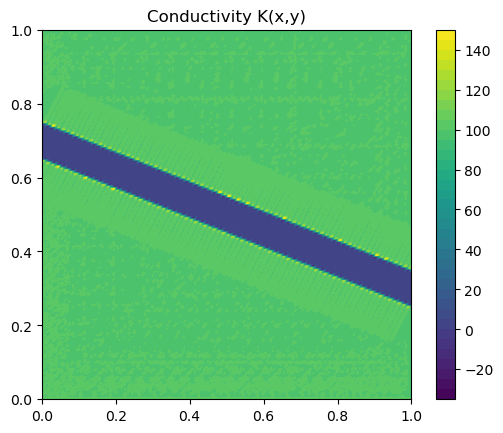

In [12]:
def plot_conductivity(parameters):
    K = get_conductivity(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="viridis")
    plt.colorbar(p)
    plt.title("Conductivity K(x,y)")
    plt.show()

K_test = get_conductivity(example_parameters)
plot_conductivity(example_parameters)

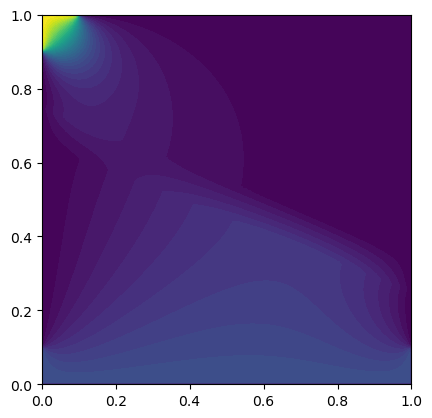

In [13]:
plot(uh_HDM_sol)

In [14]:
N_dof = V.dim()
Ns = 30
U_snapshot = np.zeros((N_dof, Ns))
print("dimension de U_snapshot:", U_snapshot.shape)

dimension de U_snapshot: (160801, 30)


In [15]:
parameters_list = []
for i in tqdm(range(Ns), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot[:, i] = uh_HDM_sol_vec
print(parameters_list)

Génération des Snapshots:   0%|          | 0/30 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   3%|▎         | 1/30 [00:15<07:17, 15.07s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   7%|▋         | 2/30 [00:19<04:02,  8.68s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  97%|█████████▋| 29/30 [02:16<00:04,  4.06s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots: 100%|██████████| 30/30 [02:20<00:00,  4.69s/it]

[{'slope': 57.79194834104509, 'position': 87.88235703084484, 'half_width': 5.209402329445892, 'D_background': 92.54044119762833, 'D_fracture': 0.865902511337777}, {'slope': 52.838743866015825, 'position': 60.604172247758726, 'half_width': 4.062735812125595, 'D_background': 103.14558100304498, 'D_fracture': 0.9642768862141291}, {'slope': 47.968420929065346, 'position': 57.37677946868911, 'half_width': 3.402390831733875, 'D_background': 97.78338539246164, 'D_fracture': 0.6999521993429774}, {'slope': 55.49587987936151, 'position': 65.57683026886083, 'half_width': 4.837806259978713, 'D_background': 119.49572869566018, 'D_fracture': 0.5874969651223529}, {'slope': 38.8704085799201, 'position': 57.681844272793725, 'half_width': 4.415162310989237, 'D_background': 110.74572680255741, 'D_fracture': 1.292342725827368}, {'slope': 57.62897813170174, 'position': 79.60111999842991, 'half_width': 4.926739812921561, 'D_background': 81.3436856843893, 'D_fracture': 1.6199627151520604}, {'slope': 39.04591

In [16]:
def numpy_to_fenics(numpy_vec, V, u_L_vect):
    """
    Reconstruit un objet Function FEniCS à partir d'un vecteur Numpy.
    """
    # 1. On crée une "boîte" FEniCS vide sur ton maillage V
    u_reconstruit = Function(V)
    
    # 2. On fait l'opération inverse mathématiquement (- au lieu de +)
    valeurs_internes = numpy_vec - u_L_vect
    
    # 3. On injecte le tableau numpy dans le vecteur FEniCS (l'inverse de get_local)
    u_reconstruit.vector().set_local(valeurs_internes)
    
    return u_reconstruit

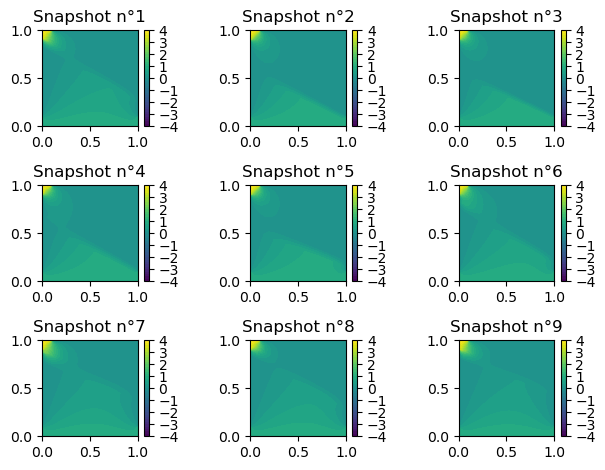

In [17]:
for i in range(9):
    vecteur_numpy = U_snapshot[:, i]    
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"Snapshot n°{i+1}")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [18]:
U, S, Vt = np.linalg.svd(U_snapshot, full_matrices=False)



number of singular values: 30
U shape: (160801, 30)
S shape: (30,)
Vt shape: (30, 30)
Singular values: [1.18028467e+03 1.33151794e+02 9.11014700e+01 6.11249305e+01
 4.74268427e+01 4.36784449e+01 3.12137214e+01 2.57136981e+01
 2.15087589e+01 1.66405463e+01 1.57030112e+01 1.36846720e+01
 1.22071001e+01 1.11824066e+01 9.99711856e+00 8.63348997e+00
 6.96169101e+00 6.38309624e+00 5.97583481e+00 5.54486400e+00
 4.49633894e+00 4.01410115e+00 3.49621940e+00 2.94164228e+00
 2.85640428e+00 2.70230973e+00 2.60512141e+00 2.19975674e+00
 2.05233289e+00 8.31031541e-01]


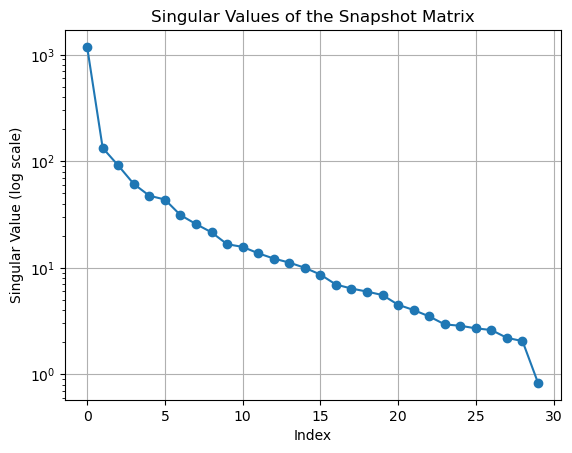

In [19]:
print("number of singular values:", len(S))
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)
plt.semilogy(S, marker='o')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

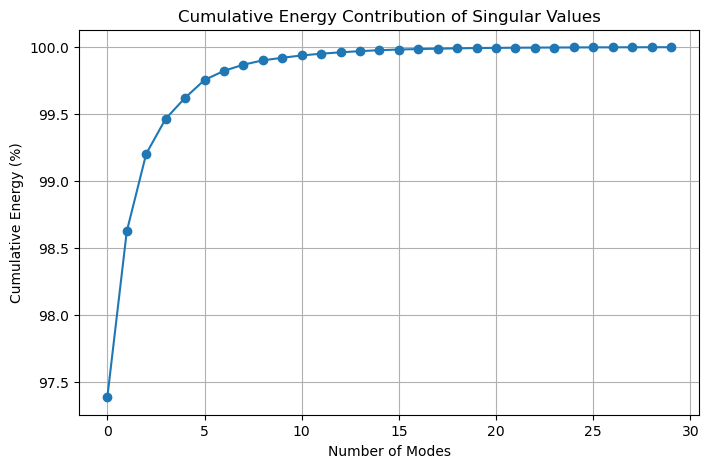

In [26]:
def plot_energy_contribution(S):
    energy = S**2
    cumulative_energy = np.cumsum(energy)
    total_energy = cumulative_energy[-1]
    energy_percentage = cumulative_energy / total_energy * 100

    plt.figure(figsize=(8, 5))
    plt.plot(energy_percentage, marker='o')
    plt.xlabel('Number of Modes')
    plt.ylabel('Cumulative Energy (%)')
    plt.title('Cumulative Energy Contribution of Singular Values')
    plt.grid()
    plt.show()
plot_energy_contribution(S)

## Un premier test

Time for ROM solve: 0.2558298110961914 seconds
Time for full HDM solve: 1.719559907913208 seconds


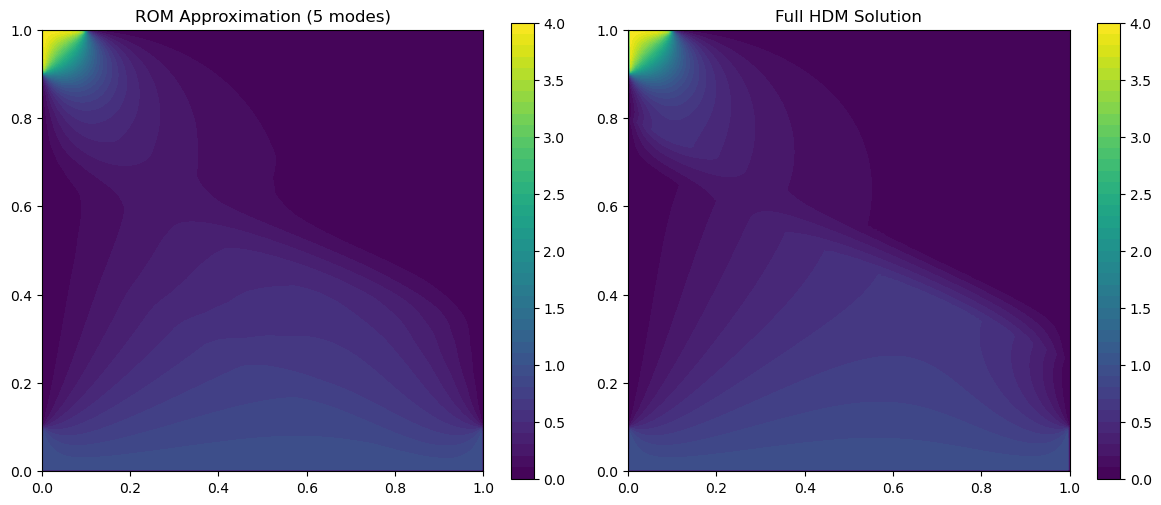

In [20]:
test_parameters = {"slope": 45.0, "position": 75.0, "half_width": 5.0, "D_background": 100.0, "D_fracture": 1.0}
t = time()
A_test, b_test = get_stiffness_and_load(test_parameters)
V_r = U[:, :5]  # les 5 premiers modes
A_red = build_reduced_stiffness(A_test, V_r)
b_red = build_reduced_load(b_test, V_r)
u_red = np.linalg.solve(A_red, b_red)
u_approx = V_r.dot(u_red) + u_L_vect
u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
print("Time for ROM solve:", time() - t, "seconds")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p1 = plot(u_approx_fenics, cmap="viridis")
plt.colorbar(p1)
plt.title("ROM Approximation (5 modes)")
plt.subplot(1, 2, 2)
t = time()
A_full, b_full = get_stiffness_and_load(test_parameters)
u_full = Function(V)
solve(A_full, u_full.vector(), b_full)
u_full_vec = np.array(u_full.vector().get_local()) + u_L_vect
u_full_fenics = numpy_to_fenics(u_full_vec, V, u_L_vect)
print("Time for full HDM solve:", time() - t, "seconds")
p2 = plot(u_full_fenics, cmap="viridis")
plt.colorbar(p2)
plt.title("Full HDM Solution")
plt.tight_layout()
plt.show()

## Qui est V1 ?

les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser


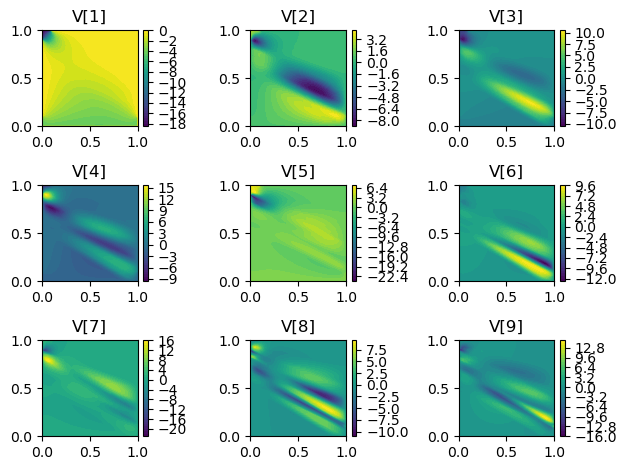

In [21]:
print("les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser")
for i in range(9):
    vecteur_numpy = U[:, i]*1000
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"V[{i+1}]")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [22]:
def error_L2(u1, u2):
    """Calcule l'erreur relative L2 entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return norm(diff, 'L2') / norm(u1, 'L2')

Error with 1 modes: 1.2706e-01
Error with 2 modes: 1.3004e-01
Error with 3 modes: 1.1128e-01
Error with 4 modes: 6.8811e-02
Error with 5 modes: 7.0052e-02
Error with 6 modes: 6.4725e-02
Error with 7 modes: 6.5207e-02
Error with 8 modes: 6.1973e-02
Error with 9 modes: 5.8867e-02
Error with 10 modes: 5.7763e-02
Error with 11 modes: 5.8881e-02
Error with 12 modes: 5.9142e-02
Error with 13 modes: 5.4374e-02
Error with 14 modes: 5.4395e-02
Error with 15 modes: 5.3582e-02
Error with 16 modes: 4.5889e-02
Error with 17 modes: 4.6139e-02
Error with 18 modes: 4.0022e-02
Error with 19 modes: 3.8706e-02
Error with 20 modes: 3.7992e-02
Error with 21 modes: 3.7735e-02
Error with 22 modes: 3.7774e-02
Error with 23 modes: 3.7185e-02
Error with 24 modes: 3.6213e-02
Error with 25 modes: 3.2351e-02
Error with 26 modes: 3.2345e-02
Error with 27 modes: 3.0394e-02
Error with 28 modes: 2.9599e-02
Error with 29 modes: 2.7297e-02
Error with 30 modes: 2.7294e-02


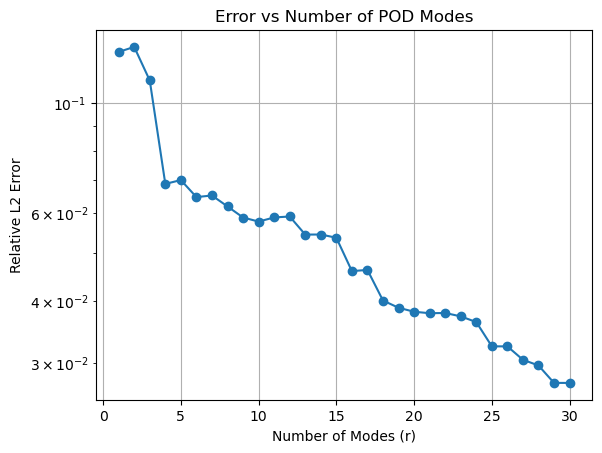

In [24]:
error = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error[r-1] = error_L2(u_full_fenics, u_approx_fenics)
    print(f"Error with {r} modes: {error[r-1]:.4e}")
plt.figure()
plt.semilogy(range(1, 31), error, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative L2 Error')
plt.title('Error vs Number of POD Modes')
plt.grid()
plt.show()

Error in A-norm with 1 modes: 2.1091e-02
Error in A-norm with 2 modes: 2.1065e-02
Error in A-norm with 3 modes: 2.0693e-02
Error in A-norm with 4 modes: 1.3406e-02
Error in A-norm with 5 modes: 1.3191e-02
Error in A-norm with 6 modes: 1.3045e-02
Error in A-norm with 7 modes: 1.2852e-02
Error in A-norm with 8 modes: 1.2723e-02
Error in A-norm with 9 modes: 1.2450e-02
Error in A-norm with 10 modes: 1.2390e-02
Error in A-norm with 11 modes: 1.2374e-02
Error in A-norm with 12 modes: 1.2350e-02
Error in A-norm with 13 modes: 1.1431e-02
Error in A-norm with 14 modes: 1.1410e-02
Error in A-norm with 15 modes: 1.1342e-02
Error in A-norm with 16 modes: 1.0689e-02
Error in A-norm with 17 modes: 1.0677e-02
Error in A-norm with 18 modes: 1.0129e-02
Error in A-norm with 19 modes: 1.0001e-02
Error in A-norm with 20 modes: 9.9020e-03
Error in A-norm with 21 modes: 9.8860e-03
Error in A-norm with 22 modes: 9.8780e-03
Error in A-norm with 23 modes: 9.7825e-03
Error in A-norm with 24 modes: 9.6595e-03
E

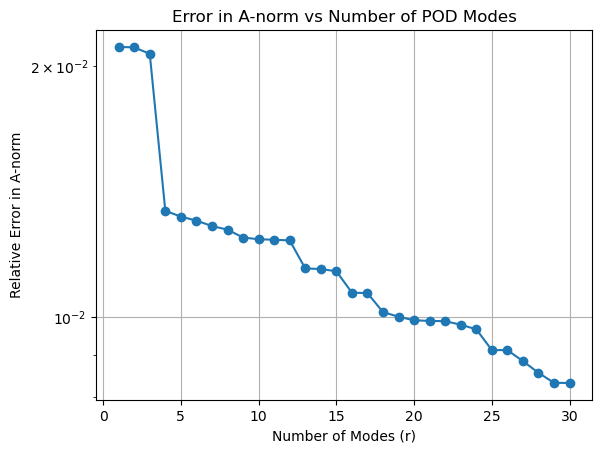

In [ ]:
def normeA(u, A):
    """Calcule la norme induite par A de la fonction u (version 100% FEniCS)."""
    # 1. On crée un vecteur FEniCS vide de la même taille que u
    Au = Vector(u.vector()) 
    
    # 2. FEniCS fait la multiplication Matrice * Vecteur (Au = A * u)
    A.mult(u.vector(), Au) 
    
    # 3. FEniCS fait le produit scalaire u^T * (Au)
    norme_A = np.sqrt(u.vector().inner(Au)) 
    
    return norme_A
def error_A_norm(u1, u2, A):
    """Calcule l'erreur relative dans la norme induite par A entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return normeA(diff, A) / normeA(u1, A)
error_A = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error_A[r-1] = error_A_norm(u_full_fenics, u_approx_fenics, A_test)
    print(f"Error in A-norm with {r} modes: {error_A[r-1]:.4e}")


plt.figure()
plt.semilogy(range(1, 31), error_A, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative Error in A-norm')
plt.title('Error in A-norm vs Number of POD Modes')
plt.grid()
plt.show()